# 🏭 Lucky Star AI System — ERP Mini Project
**Dự báo tồn kho + Chatbot RAG nội bộ**

Project này mô phỏng hệ thống AI tích hợp ERP cho nhà máy may mặc gồm:
- **Module 1**: Sinh dữ liệu giả lập ERP (tồn kho, sản xuất, đơn hàng)
- **Module 2**: Dự báo tồn kho bằng Machine Learning
- **Module 3**: RAG Chatbot trả lời câu hỏi nội bộ
- **Module 4**: Dashboard tổng hợp

---

## ⚙️ Cài đặt thư viện

In [ ]:
# Cài các thư viện cần thiết
!pip install -q openai faiss-cpu sentence-transformers scikit-learn matplotlib seaborn plotly pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 18.8 MB/s eta 0:00:00


## 📦 MODULE 1: Sinh dữ liệu giả lập ERP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ─── 1.1 Danh mục nguyên liệu ─────────────────────────────────────────────
materials = [
    {'material_id': 'VL001', 'name': 'Vải cotton trắng',   'unit': 'mét',  'reorder_point': 500,  'lead_time_days': 7},
    {'material_id': 'VL002', 'name': 'Vải thun đen',        'unit': 'mét',  'reorder_point': 400,  'lead_time_days': 5},
    {'material_id': 'VL003', 'name': 'Chỉ may trắng',       'unit': 'cuộn', 'reorder_point': 200,  'lead_time_days': 3},
    {'material_id': 'VL004', 'name': 'Khóa kéo 20cm',       'unit': 'cái',  'reorder_point': 1000, 'lead_time_days': 4},
    {'material_id': 'VL005', 'name': 'Cúc áo nhựa',         'unit': 'túi',  'reorder_point': 300,  'lead_time_days': 3},
    {'material_id': 'VL006', 'name': 'Vải lót polyester',   'unit': 'mét',  'reorder_point': 350,  'lead_time_days': 6},
    {'material_id': 'VL007', 'name': 'Nhãn mác thương hiệu','unit': 'cái',  'reorder_point': 2000, 'lead_time_days': 5},
    {'material_id': 'VL008', 'name': 'Bao bì đóng gói',     'unit': 'cái',  'reorder_point': 1500, 'lead_time_days': 4},
]
df_materials = pd.DataFrame(materials)

# ─── 1.2 Lịch sử tồn kho 180 ngày ────────────────────────────────────────
records = []
start_date = datetime(2024, 1, 1)

for mat in materials:
    stock = np.random.randint(600, 1200)
    for day in range(180):
        date = start_date + timedelta(days=day)
        # Tiêu thụ theo mùa vụ (tháng 3-5 và 9-11 cao điểm)
        month = date.month
        season_factor = 1.4 if month in [3,4,5,9,10,11] else 0.8
        consumption = max(0, np.random.normal(40 * season_factor, 12))
        stock -= consumption
        # Nhập hàng khi xuống thấp
        if stock < mat['reorder_point']:
            restock = np.random.randint(400, 800)
            stock += restock
            restocked = True
        else:
            restocked = False
        records.append({
            'date': date.strftime('%Y-%m-%d'),
            'material_id': mat['material_id'],
            'material_name': mat['name'],
            'stock_level': round(max(0, stock), 1),
            'daily_consumption': round(consumption, 1),
            'restocked': restocked,
            'reorder_point': mat['reorder_point'],
        })

df_inventory = pd.DataFrame(records)
df_inventory['date'] = pd.to_datetime(df_inventory['date'])

# ─── 1.3 Dữ liệu sản xuất (production orders) ────────────────────────────
products = ['Áo thun cổ tròn', 'Quần short kaki', 'Áo sơ mi công sở',
            'Quần jean slim', 'Váy đầm dạo phố', 'Áo khoác nhẹ']
prod_records = []
for i in range(200):
    date = start_date + timedelta(days=np.random.randint(0, 180))
    product = np.random.choice(products)
    planned = np.random.randint(200, 1000)
    actual = int(planned * np.random.uniform(0.75, 1.05))
    prod_records.append({
        'order_id': f'PO{1000+i}',
        'date': date.strftime('%Y-%m-%d'),
        'product': product,
        'line': f'Chuyền {np.random.randint(1,6)}',
        'planned_qty': planned,
        'actual_qty': actual,
        'efficiency': round(actual/planned*100, 1),
        'defect_rate': round(np.random.uniform(0.5, 4.5), 2),
    })

df_production = pd.DataFrame(prod_records)
df_production['date'] = pd.to_datetime(df_production['date'])

# ─── Lưu CSV ─────────────────────────────────────────────────────────────
df_inventory.to_csv('erp_inventory.csv', index=False)
df_production.to_csv('erp_production.csv', index=False)
df_materials.to_csv('erp_materials.csv', index=False)

print('✅ Đã tạo dữ liệu ERP giả lập!')
print(f'   - erp_inventory.csv  : {len(df_inventory):,} rows')
print(f'   - erp_production.csv : {len(df_production):,} rows')
print(f'   - erp_materials.csv  : {len(df_materials):,} rows')
df_inventory.head(3)

✅ Đã tạo dữ liệu ERP giả lập!
   - erp_inventory.csv  : 1,440 rows
   - erp_production.csv : 200 rows
   - erp_materials.csv  : 8 rows


,date,material_id,material_name,stock_level,daily_consumption,restocked,reorder_point
0,2024-01-01,VL001,Vải cotton trắng,676.6,25.4,False,500
1,2024-01-02,VL001,Vải cotton trắng,638.4,38.2,False,500
2,2024-01-03,VL001,Vải cotton trắng,600.7,37.7,False,500


## 📊 MODULE 2: Dự báo tồn kho bằng Machine Learning

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ─── 2.1 Feature Engineering ──────────────────────────────────────────────
def build_features(df):
    df = df.copy().sort_values(['material_id','date'])
    df['day_of_week']  = df['date'].dt.dayofweek
    df['month']        = df['date'].dt.month
    df['day_of_year']  = df['date'].dt.dayofyear
    df['is_high_season'] = df['month'].isin([3,4,5,9,10,11]).astype(int)

    # Lag features (tiêu thụ N ngày trước)
    for lag in [1, 3, 7, 14]:
        df[f'consumption_lag{lag}'] = df.groupby('material_id')['daily_consumption'].shift(lag)

    # Rolling stats
    for window in [7, 14, 30]:
        df[f'consumption_ma{window}']  = df.groupby('material_id')['daily_consumption'].transform(lambda x: x.rolling(window).mean())
        df[f'consumption_std{window}'] = df.groupby('material_id')['daily_consumption'].transform(lambda x: x.rolling(window).std())

    df[f'stock_ma7'] = df.groupby('material_id')['stock_level'].transform(lambda x: x.rolling(7).mean())
    df['days_until_reorder'] = df['stock_level'] - df['reorder_point']
    df['material_code'] = df['material_id'].str.replace('VL','').astype(int)
    return df.dropna()

df_feat = build_features(df_inventory)

feature_cols = [
    'stock_level', 'reorder_point', 'days_until_reorder',
    'day_of_week', 'month', 'day_of_year', 'is_high_season',
    'consumption_lag1','consumption_lag3','consumption_lag7','consumption_lag14',
    'consumption_ma7','consumption_ma14','consumption_ma30',
    'consumption_std7','consumption_std14',
    'stock_ma7','material_code'
]

X = df_feat[feature_cols]
y = df_feat['daily_consumption']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ─── 2.2 Train & Compare Models ───────────────────────────────────────────
models = {
    'Linear Regression':      LinearRegression(),
    'Random Forest':          RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'MAE':  round(mean_absolute_error(y_test, preds), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 3),
        'R²':   round(r2_score(y_test, preds), 4),
        'model': model
    }
    print(f'{name:25s} | MAE={results[name]["MAE"]:6.3f} | RMSE={results[name]["RMSE"]:6.3f} | R²={results[name]["R²"]:.4f}')

best_name = max(results, key=lambda k: results[k]['R²'])
best_model = results[best_name]['model']
print(f'\n🏆 Best model: {best_name} (R²={results[best_name]["R²"]})')

Linear Regression         | MAE= 8.899 | RMSE=11.196 | R²=0.5672
Random Forest             | MAE= 9.166 | RMSE=11.521 | R²=0.5417
Gradient Boosting         | MAE= 8.978 | RMSE=11.334 | R²=0.5565

🏆 Best model: Linear Regression (R²=0.5672)


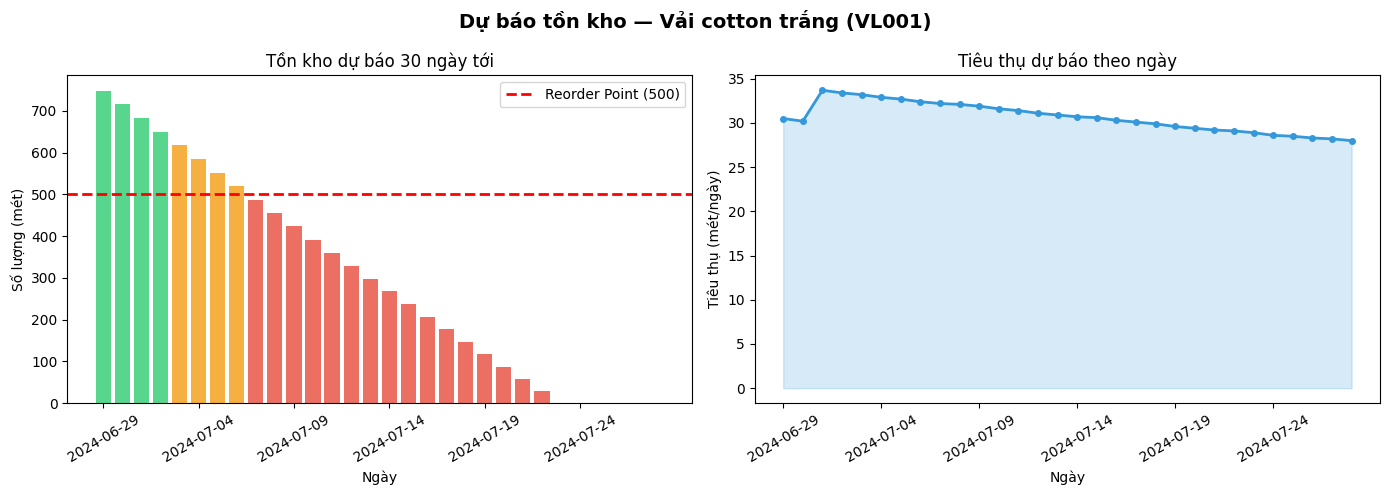


📋 Tóm tắt dự báo 30 ngày:
   ⚠️  Tồn kho xuống dưới ngưỡng từ ngày: 2024-07-07
   📦 Khuyến nghị nhập hàng trước ngày đó!


In [ ]:
# ─── 2.3 Dự báo 30 ngày tới cho từng nguyên liệu ─────────────────────────
def forecast_next_n_days(material_id, n_days=30):
    mat_df = df_feat[df_feat['material_id'] == material_id].sort_values('date')
    if mat_df.empty:
        return None
    last_row   = mat_df.iloc[-1]
    last_date  = last_row['date']
    last_stock = last_row['stock_level']
    reorder_pt = last_row['reorder_point']

    forecasts = []
    for i in range(1, n_days+1):
        future_date = last_date + timedelta(days=i)
        month = future_date.month
        row = pd.DataFrame([{
            'stock_level':         last_stock,
            'reorder_point':       reorder_pt,
            'days_until_reorder':  last_stock - reorder_pt,
            'day_of_week':         future_date.dayofweek,
            'month':               month,
            'day_of_year':         future_date.timetuple().tm_yday,
            'is_high_season':      int(month in [3,4,5,9,10,11]),
            'consumption_lag1':    last_row['daily_consumption'],
            'consumption_lag3':    last_row.get('consumption_lag3', last_row['daily_consumption']),
            'consumption_lag7':    last_row.get('consumption_lag7', last_row['daily_consumption']),
            'consumption_lag14':   last_row.get('consumption_lag14', last_row['daily_consumption']),
            'consumption_ma7':     last_row['consumption_ma7'],
            'consumption_ma14':    last_row['consumption_ma14'],
            'consumption_ma30':    last_row['consumption_ma30'],
            'consumption_std7':    last_row['consumption_std7'],
            'consumption_std14':   last_row['consumption_std14'],
            'stock_ma7':           last_row['stock_ma7'],
            'material_code':       last_row['material_code'],
        }])
        pred_consumption = max(0, best_model.predict(row)[0])
        last_stock = max(0, last_stock - pred_consumption)
        alert = '🔴 DƯỚI MỨC CẢNH BÁO' if last_stock < reorder_pt else ('🟡 Sắp tới ngưỡng' if last_stock < reorder_pt*1.3 else '🟢 Bình thường')
        forecasts.append({
            'date': future_date.strftime('%Y-%m-%d'),
            'predicted_consumption': round(pred_consumption, 1),
            'projected_stock': round(last_stock, 1),
            'reorder_point': reorder_pt,
            'status': alert
        })
    return pd.DataFrame(forecasts)

# Demo với VL001
fc = forecast_next_n_days('VL001', 30)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dự báo tồn kho — Vải cotton trắng (VL001)', fontsize=14, fontweight='bold')

# Chart 1: Projected stock
colors = ['#e74c3c' if s.startswith('🔴') else ('#f39c12' if s.startswith('🟡') else '#2ecc71') for s in fc['status']]
axes[0].bar(range(len(fc)), fc['projected_stock'], color=colors, alpha=0.8)
axes[0].axhline(y=fc['reorder_point'].iloc[0], color='red', linestyle='--', linewidth=2, label=f'Reorder Point ({fc["reorder_point"].iloc[0]})')
axes[0].set_title('Tồn kho dự báo 30 ngày tới')
axes[0].set_xlabel('Ngày')
axes[0].set_ylabel('Số lượng (mét)')
axes[0].legend()
axes[0].set_xticks(range(0, 30, 5))
axes[0].set_xticklabels([fc['date'].iloc[i][:10] for i in range(0, 30, 5)], rotation=30)

# Chart 2: Consumption forecast
axes[1].plot(range(len(fc)), fc['predicted_consumption'], color='#3498db', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(range(len(fc)), fc['predicted_consumption'], alpha=0.2, color='#3498db')
axes[1].set_title('Tiêu thụ dự báo theo ngày')
axes[1].set_xlabel('Ngày')
axes[1].set_ylabel('Tiêu thụ (mét/ngày)')
axes[1].set_xticks(range(0, 30, 5))
axes[1].set_xticklabels([fc['date'].iloc[i][:10] for i in range(0, 30, 5)], rotation=30)

plt.tight_layout()
plt.savefig('forecast_VL001.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n📋 Tóm tắt dự báo 30 ngày:')
warning_days = fc[fc['status'].str.startswith('🔴')]
if not warning_days.empty:
    print(f'   ⚠️  Tồn kho xuống dưới ngưỡng từ ngày: {warning_days["date"].iloc[0]}')
    print(f'   📦 Khuyến nghị nhập hàng trước ngày đó!')
else:
    print('   ✅ Tồn kho ổn định trong 30 ngày tới.')

In [ ]:
# ─── 2.4 Summary Dashboard: Tất cả nguyên liệu ───────────────────────────
summary_rows = []
for mat in materials:
    mid = mat['material_id']
    fc_all = forecast_next_n_days(mid, 30)
    if fc_all is None:
        continue
    current_stock = df_feat[df_feat['material_id']==mid]['stock_level'].iloc[-1]
    days_to_reorder = None
    for _, row in fc_all.iterrows():
        if row['projected_stock'] < mat['reorder_point']:
            days_to_reorder = (pd.to_datetime(row['date']) - df_feat['date'].max()).days
            break
    avg_daily = fc_all['predicted_consumption'].mean()
    summary_rows.append({
        'ID': mid,
        'Nguyên liệu': mat['name'],
        'Tồn kho hiện tại': round(current_stock, 0),
        'Reorder Point': mat['reorder_point'],
        'TB tiêu thụ/ngày': round(avg_daily, 1),
        'Ngày đến ngưỡng': days_to_reorder if days_to_reorder else '>30 ngày',
        'Trạng thái': '🔴 Cần nhập gấp' if (days_to_reorder and days_to_reorder <= 7)
                      else ('🟡 Theo dõi' if (days_to_reorder and days_to_reorder <= 14)
                      else '🟢 Ổn định')
    })

df_summary = pd.DataFrame(summary_rows)
print('📊 BẢNG TỔNG HỢP DỰ BÁO TỒN KHO — 30 NGÀY TỚI')
print('='*80)
print(df_summary.to_string(index=False))
df_summary.to_csv('forecast_summary.csv', index=False)
print('\n✅ Đã lưu forecast_summary.csv')

📊 BẢNG TỔNG HỢP DỰ BÁO TỒN KHO — 30 NGÀY TỚI
   ID          Nguyên liệu  Tồn kho hiện tại  Reorder Point  TB tiêu thụ/ngày  Ngày đến ngưỡng     Trạng thái
VL001     Vải cotton trắng             778.0            500              30.7                9     🟡 Theo dõi
VL002         Vải thun đen             906.0            400              27.5               18      🟢 Ổn định
VL003        Chỉ may trắng             438.0            200              17.3               13     🟡 Theo dõi
VL004        Khóa kéo 20cm            1604.0           1000              37.9               16      🟢 Ổn định
VL005          Cúc áo nhựa             359.0            300              30.1                3 🔴 Cần nhập gấp
VL006    Vải lót polyester             545.0            350              29.5                7 🔴 Cần nhập gấp
VL007 Nhãn mác thương hiệu            2169.0           2000              31.1                6 🔴 Cần nhập gấp
VL008      Bao bì đóng gói            1913.0           1500              22

## 🤖 MODULE 3: RAG Chatbot nội bộ

In [ ]:
# ─── 3.1 Xây Knowledge Base (tài liệu nội bộ giả lập) ────────────────────
# Đây là các tài liệu mà chatbot sẽ "đọc" và trả lời dựa vào

KNOWLEDGE_BASE = [
    {
        'doc_id': 'SOP_001',
        'title': 'Quy trình nhập kho nguyên liệu',
        'content': '''Quy trình nhập kho nguyên liệu tại Lucky Star:
1. Bộ phận mua hàng tạo Purchase Order (PO) trên ERP khi tồn kho xuống dưới reorder point.
2. Khi hàng về, thủ kho kiểm tra số lượng và chất lượng so với PO.
3. Nếu đạt: thực hiện GRN (Goods Receipt Note) trên hệ thống ERP.
4. Nếu không đạt: lập biên bản và liên hệ nhà cung cấp trong vòng 24 giờ.
5. Cập nhật tồn kho hệ thống trong vòng 2 tiếng sau khi nhập.
Mức tồn kho tối thiểu (reorder point): Vải cotton 500m, Vải thun 400m, Chỉ may 200 cuộn.'''
    },
    {
        'doc_id': 'SOP_002',
        'title': 'Quy trình kiểm soát chất lượng (QC)',
        'content': '''Tiêu chuẩn QC sản phẩm tại Lucky Star:
- Tỷ lệ lỗi cho phép (defect rate): tối đa 2.5% trên tổng sản phẩm.
- Kiểm tra 100% lô hàng xuất khẩu, 30% lô hàng nội địa.
- Lỗi phân loại: Lỗi A (nghiêm trọng - loại bỏ), Lỗi B (sửa được), Lỗi C (chấp nhận được).
- Báo cáo QC gửi trưởng chuyền mỗi 2 tiếng/lần.
- Nếu defect rate > 3%: dừng chuyền, báo kỹ thuật ngay lập tức.
- Công cụ QC sử dụng: thước dây, máy đo màu, bàn kiểm tra ánh sáng trắng.'''
    },
    {
        'doc_id': 'SOP_003',
        'title': 'KPI và hiệu suất sản xuất',
        'content': '''Các chỉ số KPI nhà máy Lucky Star:
- OEE (Overall Equipment Effectiveness) mục tiêu: ≥ 80%.
- Hiệu suất chuyền (efficiency) mục tiêu: ≥ 90% kế hoạch.
- Năng suất trung bình: 800-1000 sản phẩm/chuyền/ngày.
- Nhà máy có 5 chuyền may, hoạt động 2 ca (6h-14h và 14h-22h).
- Sản phẩm chủ lực: áo thun, quần jean, áo sơ mi, váy đầm.
- Tháng cao điểm: tháng 3-5 (hàng hè) và tháng 9-11 (hàng đông).'''
    },
    {
        'doc_id': 'SOP_004',
        'title': 'Hướng dẫn vận hành hệ thống ERP',
        'content': '''Hệ thống ERP tại Lucky Star sử dụng Odoo 16:
- Module Inventory: quản lý tồn kho nguyên liệu và thành phẩm.
- Module Manufacturing: lập kế hoạch và theo dõi lệnh sản xuất.
- Module Purchase: quản lý đơn mua hàng và nhà cung cấp.
- Module Sales: quản lý đơn hàng khách và xuất kho.
- Module Accounting: kế toán và báo cáo tài chính.
Đăng nhập: erp.luckystar.vn | Hỗ trợ IT: ext 1001 | Backup dữ liệu: 23h00 hàng ngày.'''
    },
    {
        'doc_id': 'SOP_005',
        'title': 'Nhà cung cấp nguyên liệu chính',
        'content': '''Danh sách nhà cung cấp chính Lucky Star:
1. Vải Phong Phú (HCM): cung cấp vải cotton, vải thun - lead time 5-7 ngày.
2. Chỉ Coats Việt Nam: cung cấp chỉ may các loại - lead time 3-4 ngày.
3. Khóa YKK: cung cấp khóa kéo cao cấp - lead time 7-10 ngày.
4. Bao bì Tân Tiến: cung cấp bao bì đóng gói - lead time 3-5 ngày.
Chính sách: ưu tiên đặt hàng trước 14 ngày để đảm bảo nguồn cung.
Liên hệ mua hàng: Ms. Lan - 0901 234 567 | Mr. Hùng - 0912 345 678.'''
    },
    {
        'doc_id': 'RPT_001',
        'title': 'Báo cáo sản xuất tháng 6/2024',
        'content': '''Tóm tắt sản xuất tháng 6/2024:
- Tổng sản phẩm hoàn thành: 48,250 / kế hoạch 50,000 (đạt 96.5%).
- Chuyền hiệu suất cao nhất: Chuyền 2 (97.3%).
- Chuyền cần cải thiện: Chuyền 4 (82.1%) - do máy móng tay bị lỗi ngày 15/6.
- Defect rate trung bình: 1.8% (dưới ngưỡng 2.5% - đạt).
- Tiêu thụ vải cotton: 6,200m; vải thun: 4,800m.
- Chi phí nguyên liệu: 1.2 tỷ VNĐ (trong ngân sách).'''
    },
]

print(f'📚 Knowledge Base đã có {len(KNOWLEDGE_BASE)} tài liệu nội bộ')
for doc in KNOWLEDGE_BASE:
    print(f'   [{doc["doc_id"]}] {doc["title"]}')

📚 Knowledge Base đã có 6 tài liệu nội bộ
   [SOP_001] Quy trình nhập kho nguyên liệu
   [SOP_002] Quy trình kiểm soát chất lượng (QC)
   [SOP_003] KPI và hiệu suất sản xuất
   [SOP_004] Hướng dẫn vận hành hệ thống ERP
   [SOP_005] Nhà cung cấp nguyên liệu chính
   [RPT_001] Báo cáo sản xuất tháng 6/2024


In [ ]:
# ─── 3.2 Vector Store với FAISS ───────────────────────────────────────────
from sentence_transformers import SentenceTransformer
import faiss
import pickle

print('⏳ Đang load embedding model (multilingual)...')
# Model hỗ trợ tiếng Việt tốt
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Tạo embeddings cho toàn bộ knowledge base
docs_text = [f"{doc['title']}\n{doc['content']}" for doc in KNOWLEDGE_BASE]
print('⏳ Đang tạo vector embeddings...')
embeddings = embedder.encode(docs_text, show_progress_bar=True)

# Tạo FAISS index
dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)  # Inner product (cosine similarity)
faiss.normalize_L2(embeddings)
index.add(embeddings)

print(f'\n✅ Vector store đã sẵn sàng!')
print(f'   Số documents: {index.ntotal}')
print(f'   Embedding dimension: {dim}')

def retrieve_relevant_docs(query, top_k=2):
    """Tìm tài liệu liên quan nhất cho câu hỏi."""
    query_vec = embedder.encode([query])
    faiss.normalize_L2(query_vec)
    scores, indices = index.search(query_vec, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx >= 0:
            results.append({
                'doc': KNOWLEDGE_BASE[idx],
                'score': float(score)
            })
    return results

# Test retrieval
test_query = 'quy trình nhập kho khi tồn kho thấp'
results = retrieve_relevant_docs(test_query)
print(f'\n🔍 Test retrieval: "{test_query}"')
for r in results:
    print(f'   → [{r["doc"]["doc_id"]}] {r["doc"]["title"]} (score={r["score"]:.3f})')

⏳ Đang load embedding model (multilingual)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

⏳ Đang tạo vector embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Vector store đã sẵn sàng!
   Số documents: 6
   Embedding dimension: 384

🔍 Test retrieval: "quy trình nhập kho khi tồn kho thấp"
   → [SOP_001] Quy trình nhập kho nguyên liệu (score=0.503)
   → [SOP_003] KPI và hiệu suất sản xuất (score=0.342)


In [ ]:
# ─── 3.3 Lấy dữ liệu ERP real-time để bổ sung context ────────────────────
def get_erp_context():
    """Lấy snapshot dữ liệu ERP hiện tại để đưa vào context chatbot."""
    latest = df_inventory.sort_values('date').groupby('material_id').last().reset_index()
    erp_snapshot = 'DỮ LIỆU ERP HIỆN TẠI:\n'
    for _, row in latest.iterrows():
        status = '⚠️ DƯỚI NGƯỠNG' if row['stock_level'] < row['reorder_point'] else 'OK'
        erp_snapshot += f"- {row['material_name']} ({row['material_id']}): tồn {row['stock_level']:.0f} {df_materials[df_materials['material_id']==row['material_id']]['unit'].values[0]} [{status}]\n"

    # Thêm summary sản xuất
    recent_prod = df_production.sort_values('date').tail(10)
    avg_eff = recent_prod['efficiency'].mean()
    avg_defect = recent_prod['defect_rate'].mean()
    erp_snapshot += f"\nSẢN XUẤT GẦN ĐÂY (10 lệnh cuối):\n"
    erp_snapshot += f"- Hiệu suất trung bình: {avg_eff:.1f}%\n"
    erp_snapshot += f"- Tỷ lệ lỗi trung bình: {avg_defect:.2f}%\n"
    return erp_snapshot

erp_context = get_erp_context()
print(erp_context)

DỮ LIỆU ERP HIỆN TẠI:
- Vải cotton trắng (VL001): tồn 778 mét [OK]
- Vải thun đen (VL002): tồn 906 mét [OK]
- Chỉ may trắng (VL003): tồn 438 cuộn [OK]
- Khóa kéo 20cm (VL004): tồn 1604 cái [OK]
- Cúc áo nhựa (VL005): tồn 359 túi [OK]
- Vải lót polyester (VL006): tồn 545 mét [OK]
- Nhãn mác thương hiệu (VL007): tồn 2169 cái [OK]
- Bao bì đóng gói (VL008): tồn 1913 cái [OK]

SẢN XUẤT GẦN ĐÂY (10 lệnh cuối):
- Hiệu suất trung bình: 92.2%
- Tỷ lệ lỗi trung bình: 1.99%



In [ ]:
# ─── 3.4 RAG Chatbot với Claude API (hoặc OpenAI) ─────────────────────────
import os

# Nhập API key (dùng một trong hai)
# Option A - Claude (Anthropic):
ANTHROPIC_API_KEY = input('🔑 Nhập Anthropic API Key (hoặc Enter để dùng mock mode): ').strip()
# Option B - OpenAI: OPENAI_API_KEY = input('Nhập OpenAI API key: ')

USE_MOCK = not bool(ANTHROPIC_API_KEY)

if not USE_MOCK:
    try:
        import anthropic
    except ImportError:
        !pip install -q anthropic
        import anthropic
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    print('✅ Đã kết nối Anthropic API')
else:
    print('⚡ Chạy ở MOCK MODE (không cần API key)')

# ─── Hàm chat chính ───────────────────────────────────────────────────────
def rag_chat(user_question, chat_history=None):
    """RAG Chatbot: Retrieve → Augment → Generate."""
    if chat_history is None:
        chat_history = []

    # STEP 1: RETRIEVE — tìm tài liệu liên quan
    relevant_docs = retrieve_relevant_docs(user_question, top_k=2)
    retrieved_context = '\n\n'.join([
        f"[{r['doc']['doc_id']}] {r['doc']['title']}:\n{r['doc']['content']}"
        for r in relevant_docs
    ])

    # STEP 2: AUGMENT — xây dựng prompt
    system_prompt = f"""Bạn là AI Assistant nội bộ của nhà máy may mặc Lucky Star Việt Nam.
Nhiệm vụ: Trả lời câu hỏi của nhân viên dựa trên tài liệu nội bộ và dữ liệu ERP.
Nguyên tắc: Chỉ trả lời dựa trên thông tin được cung cấp. Nếu không có thông tin, nói rõ.
Trả lời bằng tiếng Việt, súc tích, chuyên nghiệp.

=== TÀI LIỆU NỘI BỘ LIÊN QUAN ===
{retrieved_context}

=== {get_erp_context()} ==="""

    if USE_MOCK:
        # Mock response dựa trên retrieved docs
        return {
            'answer': f"[MOCK MODE - Cần API key để có câu trả lời thực]\n\nTài liệu tìm thấy:\n" +
                      "\n".join([f"• [{r['doc']['doc_id']}] {r['doc']['title']}" for r in relevant_docs]) +
                      f"\n\nNội dung liên quan:\n{relevant_docs[0]['doc']['content'][:300]}...",
            'sources': [r['doc']['doc_id'] for r in relevant_docs],
            'retrieved_docs': relevant_docs
        }

    # STEP 3: GENERATE
    messages = chat_history + [{'role': 'user', 'content': user_question}]
    response = client.messages.create(
        model='claude-opus-4-5',
        max_tokens=1024,
        system=system_prompt,
        messages=messages
    )
    answer = response.content[0].text
    return {
        'answer': answer,
        'sources': [r['doc']['doc_id'] for r in relevant_docs],
        'retrieved_docs': relevant_docs
    }

print('✅ RAG Chatbot đã sẵn sàng!')

In [ ]:
# ─── 3.4 RAG Chatbot với Claude API (hoặc OpenAI) ─────────────────────────
import os

# Nhập API key (dùng một trong hai)
# Option A - Claude (Anthropic):
ANTHROPIC_API_KEY = input('🔑 Nhập Anthropic API Key (hoặc Enter để dùng mock mode): ').strip()
# Option B - OpenAI: OPENAI_API_KEY = input('Nhập OpenAI API key: ')

USE_MOCK = not bool(ANTHROPIC_API_KEY)

if not USE_MOCK:
    try:
        import anthropic
    except ImportError:
        !pip install -q anthropic
        import anthropic
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    print('✅ Đã kết nối Anthropic API')
else:
    print('⚡ Chạy ở MOCK MODE (không cần API key)')

# ─── Hàm chat chính ───────────────────────────────────────────────────────
def rag_chat(user_question, chat_history=None):
    """RAG Chatbot: Retrieve → Augment → Generate."""
    if chat_history is None:
        chat_history = []

    # STEP 1: RETRIEVE — tìm tài liệu liên quan
    relevant_docs = retrieve_relevant_docs(user_question, top_k=2)
    retrieved_context = '\n\n'.join([
        f"[{r['doc']['doc_id']}] {r['doc']['title']}:\n{r['doc']['content']}"
        for r in relevant_docs
    ])

    # STEP 2: AUGMENT — xây dựng prompt
    system_prompt = f"""Bạn là AI Assistant nội bộ của nhà máy may mặc Lucky Star Việt Nam.
Nhiệm vụ: Trả lời câu hỏi của nhân viên dựa trên tài liệu nội bộ và dữ liệu ERP.
Nguyên tắc: Chỉ trả lời dựa trên thông tin được cung cấp. Nếu không có thông tin, nói rõ.
Trả lời bằng tiếng Việt, súc tích, chuyên nghiệp.

=== TÀI LIỆU NỘI BỘ LIÊN QUAN ===
{retrieved_context}

=== {get_erp_context()} ==="""

    if USE_MOCK:
        # Mock response dựa trên retrieved docs
        return {
            'answer': f"[MOCK MODE - Cần API key để có câu trả lời thực]\n\nTài liệu tìm thấy:\n" +
                      "\n".join([f"• [{r['doc']['doc_id']}] {r['doc']['title']}" for r in relevant_docs]) +
                      f"\n\nNội dung liên quan:\n{relevant_docs[0]['doc']['content'][:300]}...",
            'sources': [r['doc']['doc_id'] for r in relevant_docs],
            'retrieved_docs': relevant_docs
        }

    # STEP 3: GENERATE
    messages = chat_history + [{'role': 'user', 'content': user_question}]
    response = client.messages.create(
        model='claude-opus-4-5',
        max_tokens=1024,
        system=system_prompt,
        messages=messages
    )
    answer = response.content[0].text
    return {
        'answer': answer,
        'sources': [r['doc']['doc_id'] for r in relevant_docs],
        'retrieved_docs': relevant_docs
    }

print('✅ RAG Chatbot đã sẵn sàng!')

🔑 Nhập Anthropic API Key (hoặc Enter để dùng mock mode): 
⚡ Chạy ở MOCK MODE (không cần API key)
✅ RAG Chatbot đã sẵn sàng!


In [ ]:
# ─── 3.5 Interactive Chat Loop ────────────────────────────────────────────
print('='*60)
print('🤖 LUCKY STAR AI ASSISTANT')
print('   Nhập câu hỏi (gõ "quit" để thoát)')
print('='*60)

# Demo các câu hỏi mẫu
sample_questions = [
    'Reorder point của vải cotton là bao nhiêu?',
    'Tỷ lệ lỗi cho phép là bao nhiêu phần trăm?',
    'Khi nào cần dừng chuyền sản xuất?',
    'Nhà cung cấp chỉ may là ai?',
    'Tình trạng tồn kho hiện tại thế nào?',
]

print('\n💡 Câu hỏi mẫu:')
for i, q in enumerate(sample_questions, 1):
    print(f'   {i}. {q}')

chat_history = []
print()

# Chạy một số câu hỏi demo tự động
for question in sample_questions[:3]:
    print(f'\n👤 Câu hỏi: {question}')
    result = rag_chat(question, chat_history)
    print(f'🤖 Trả lời: {result["answer"]}')
    print(f'📎 Nguồn: {result["sources"]}')
    print('-'*50)
    if not USE_MOCK:
        chat_history.extend([
            {'role': 'user', 'content': question},
            {'role': 'assistant', 'content': result['answer']}
        ])

🤖 LUCKY STAR AI ASSISTANT
   Nhập câu hỏi (gõ "quit" để thoát)

💡 Câu hỏi mẫu:
   1. Reorder point của vải cotton là bao nhiêu?
   2. Tỷ lệ lỗi cho phép là bao nhiêu phần trăm?
   3. Khi nào cần dừng chuyền sản xuất?
   4. Nhà cung cấp chỉ may là ai?
   5. Tình trạng tồn kho hiện tại thế nào?


👤 Câu hỏi: Reorder point của vải cotton là bao nhiêu?
🤖 Trả lời: [MOCK MODE - Cần API key để có câu trả lời thực]

Tài liệu tìm thấy:
• [RPT_001] Báo cáo sản xuất tháng 6/2024
• [SOP_005] Nhà cung cấp nguyên liệu chính

Nội dung liên quan:
Tóm tắt sản xuất tháng 6/2024:
- Tổng sản phẩm hoàn thành: 48,250 / kế hoạch 50,000 (đạt 96.5%).
- Chuyền hiệu suất cao nhất: Chuyền 2 (97.3%).
- Chuyền cần cải thiện: Chuyền 4 (82.1%) - do máy móng tay bị lỗi ngày 15/6.
- Defect rate trung bình: 1.8% (dưới ngưỡng 2.5% - đạt).
- Tiêu thụ vải cotton:...
📎 Nguồn: ['RPT_001', 'SOP_005']
--------------------------------------------------

👤 Câu hỏi: Tỷ lệ lỗi cho phép là bao nhiêu phần trăm?
🤖 Trả lời: [MOCK MODE 

In [ ]:
# ─── 3.6 Chat tương tác (tuỳ chọn) ───────────────────────────────────────
# Uncomment để chạy chat tương tác thực sự

chat_history = []
ID_USER = input("Đăng nhập: ")
while True:
    user_input = input(f"\n👤 {ID_USER}: ").strip()
    if user_input.lower() in ['quit', 'exit', 'thoát']:
        print("👋 Tạm biệt!")
        break
    if not user_input:
        continue
    result = rag_chat(user_input, chat_history)
    print(f"🤖 AI: {result['answer']}")
    print(f"📎 [{', '.join(result['sources'])}]")
    if not USE_MOCK:
        chat_history.extend([
            {"role": "user", "content": user_input},
            {"role": "assistant", "content": result["answer"]}
        ])

#print('💡 Uncomment đoạn code trên để chạy chat tương tác!')

Đăng nhập: Phung

👤 Phung: 5
🤖 AI: [MOCK MODE - Cần API key để có câu trả lời thực]

Tài liệu tìm thấy:
• [RPT_001] Báo cáo sản xuất tháng 6/2024
• [SOP_002] Quy trình kiểm soát chất lượng (QC)

Nội dung liên quan:
Tóm tắt sản xuất tháng 6/2024:
- Tổng sản phẩm hoàn thành: 48,250 / kế hoạch 50,000 (đạt 96.5%).
- Chuyền hiệu suất cao nhất: Chuyền 2 (97.3%).
- Chuyền cần cải thiện: Chuyền 4 (82.1%) - do máy móng tay bị lỗi ngày 15/6.
- Defect rate trung bình: 1.8% (dưới ngưỡng 2.5% - đạt).
- Tiêu thụ vải cotton:...
📎 [RPT_001, SOP_002]

👤 Phung: 1
🤖 AI: [MOCK MODE - Cần API key để có câu trả lời thực]

Tài liệu tìm thấy:
• [SOP_002] Quy trình kiểm soát chất lượng (QC)
• [SOP_003] KPI và hiệu suất sản xuất

Nội dung liên quan:
Tiêu chuẩn QC sản phẩm tại Lucky Star:
- Tỷ lệ lỗi cho phép (defect rate): tối đa 2.5% trên tổng sản phẩm.
- Kiểm tra 100% lô hàng xuất khẩu, 30% lô hàng nội địa.
- Lỗi phân loại: Lỗi A (nghiêm trọng - loại bỏ), Lỗi B (sửa được), Lỗi C (chấp nhận được).
- Báo cáo QC

## 📈 MODULE 4: Dashboard Tổng Hợp

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        '📦 Tồn kho hiện tại vs Reorder Point',
        '📉 Lịch sử tiêu thụ VL001 (90 ngày)',
        '🏭 Hiệu suất chuyền sản xuất',
        '🎯 Dự báo tồn kho 30 ngày — VL001'
    ],
    specs=[[{'type':'bar'},{'type':'scatter'}],
           [{'type':'bar'},{'type':'scatter'}]]
)

# Chart 1: Stock vs reorder point
latest = df_inventory.sort_values('date').groupby(['material_id','material_name']).last().reset_index()
colors_bar = ['#e74c3c' if s < r else '#2ecc71'
              for s, r in zip(latest['stock_level'], latest['reorder_point'])]
fig.add_trace(go.Bar(
    x=latest['material_name'], y=latest['stock_level'],
    name='Tồn kho', marker_color=colors_bar, showlegend=False
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=latest['material_name'], y=latest['reorder_point'],
    mode='markers', marker=dict(color='red', size=8, symbol='line-ew-open'),
    name='Reorder Point', showlegend=False
), row=1, col=1)

# Chart 2: Lịch sử tiêu thụ
vl001 = df_inventory[df_inventory['material_id']=='VL001'].tail(90)
fig.add_trace(go.Scatter(
    x=vl001['date'], y=vl001['daily_consumption'].rolling(7).mean(),
    mode='lines', line=dict(color='#3498db', width=2),
    name='MA7 tiêu thụ', showlegend=False
), row=1, col=2)

# Chart 3: Hiệu suất theo chuyền
eff_by_line = df_production.groupby('line')['efficiency'].mean().reset_index()
bar_colors = ['#e74c3c' if e < 85 else ('#f39c12' if e < 92 else '#2ecc71')
              for e in eff_by_line['efficiency']]
fig.add_trace(go.Bar(
    x=eff_by_line['line'], y=eff_by_line['efficiency'],
    marker_color=bar_colors, showlegend=False,
    text=[f'{v:.1f}%' for v in eff_by_line['efficiency']], textposition='auto'
), row=2, col=1)

# Chart 4: Forecast
fc30 = forecast_next_n_days('VL001', 30)
fc_colors = ['#e74c3c' if s < 500 else '#2ecc71' for s in fc30['projected_stock']]
fig.add_trace(go.Bar(
    x=fc30['date'], y=fc30['projected_stock'],
    marker_color=fc_colors, name='Tồn kho dự báo', showlegend=False
), row=2, col=2)
fig.add_hline(y=500, line_dash='dash', line_color='red', row=2, col=2)

fig.update_layout(
    title=dict(text='🏭 LUCKY STAR — ERP AI DASHBOARD', font=dict(size=20)),
    height=750,
    paper_bgcolor='#f8f9fa',
    plot_bgcolor='white',
)
fig.update_xaxes(tickangle=45)
fig.show()
print('✅ Dashboard đã render!')

✅ Dashboard đã render!


---
## ✅ Tóm tắt Project

| Module | Kỹ thuật | Kết quả |
|--------|----------|---------|
| Data Generation | pandas, numpy | 3 CSV files giả lập ERP |
| Forecasting | Random Forest, Feature Engineering | Dự báo tồn kho 30 ngày |
| Vector Store | FAISS + SentenceTransformers | Tìm kiếm tài liệu semantic |
| RAG Chatbot | Claude/OpenAI API + RAG | Chatbot hỏi đáp nội bộ |
| Dashboard | Plotly | Visualize realtime |

**🎯 Điểm nổi bật của demo:**
- Dùng **FAISS** cho vector search (production-grade)
- **Multilingual embedding** hỗ trợ tiếng Việt
- **Feature engineering** với lag features và rolling stats
- RAG **kết hợp cả tài liệu + live ERP data** vào context
- Kiến trúc có thể mở rộng thực tế với Odoo API